# **Meta Display Whatsapp Throughput Plots**

Parsing RB_Display_G2P_test_Messenger_Cal.txt...


/var/folders/rn/4nj37fp17b186g3qlc229y440000gn/T/ipykernel_51335/1465932592.py:96: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  resampled = subset['bytes'].resample(f'{window_seconds}S').sum()
/var/folders/rn/4nj37fp17b186g3qlc229y440000gn/T/ipykernel_51335/1465932592.py:96: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  resampled = subset['bytes'].resample(f'{window_seconds}S').sum()


Parsing RB_Display_G2P_test_Whatsapp_Call.txt...


/var/folders/rn/4nj37fp17b186g3qlc229y440000gn/T/ipykernel_51335/1465932592.py:96: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  resampled = subset['bytes'].resample(f'{window_seconds}S').sum()
/var/folders/rn/4nj37fp17b186g3qlc229y440000gn/T/ipykernel_51335/1465932592.py:96: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  resampled = subset['bytes'].resample(f'{window_seconds}S').sum()


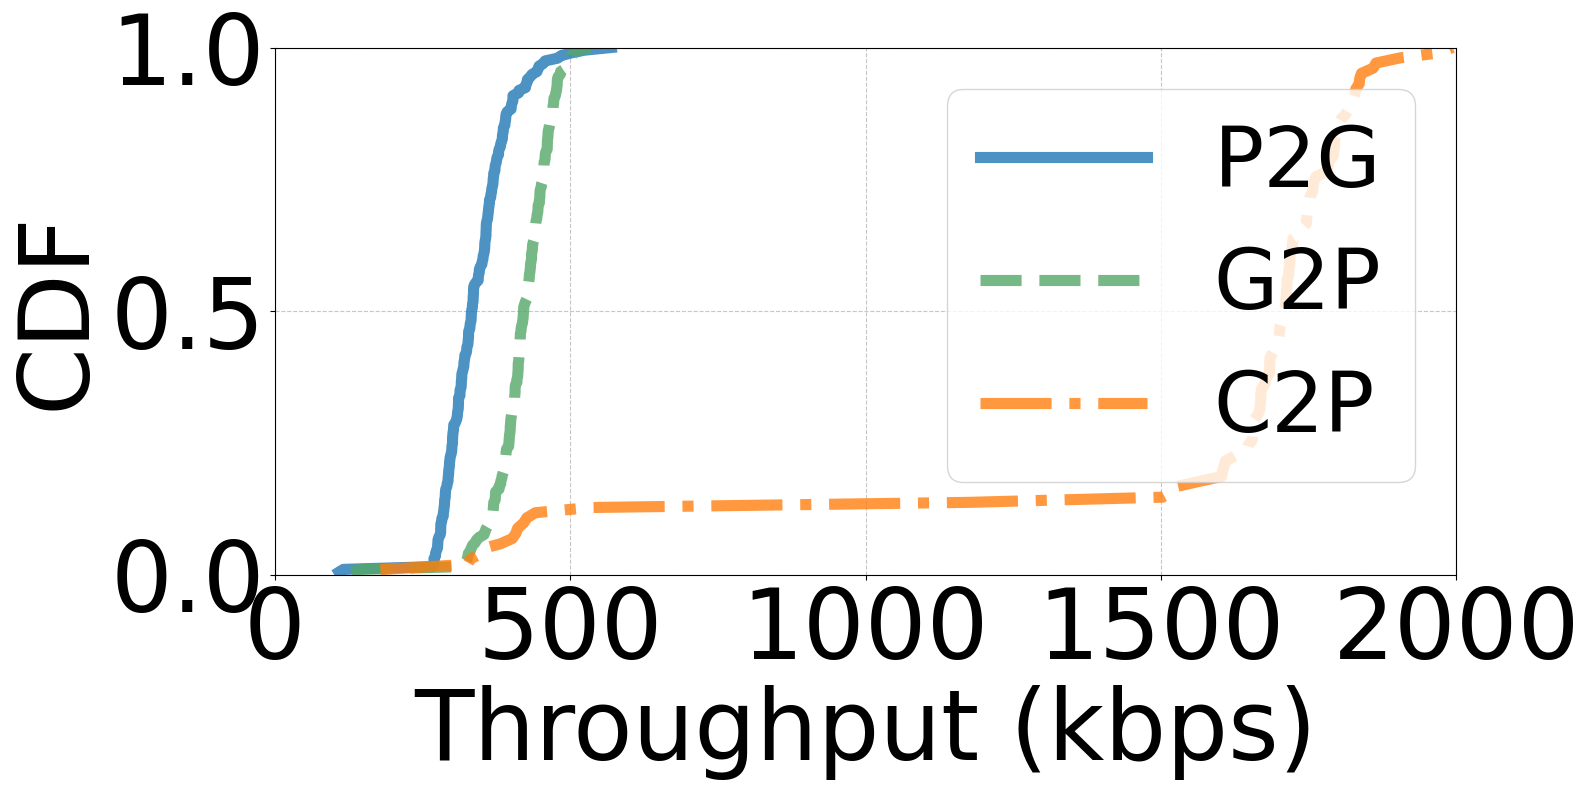

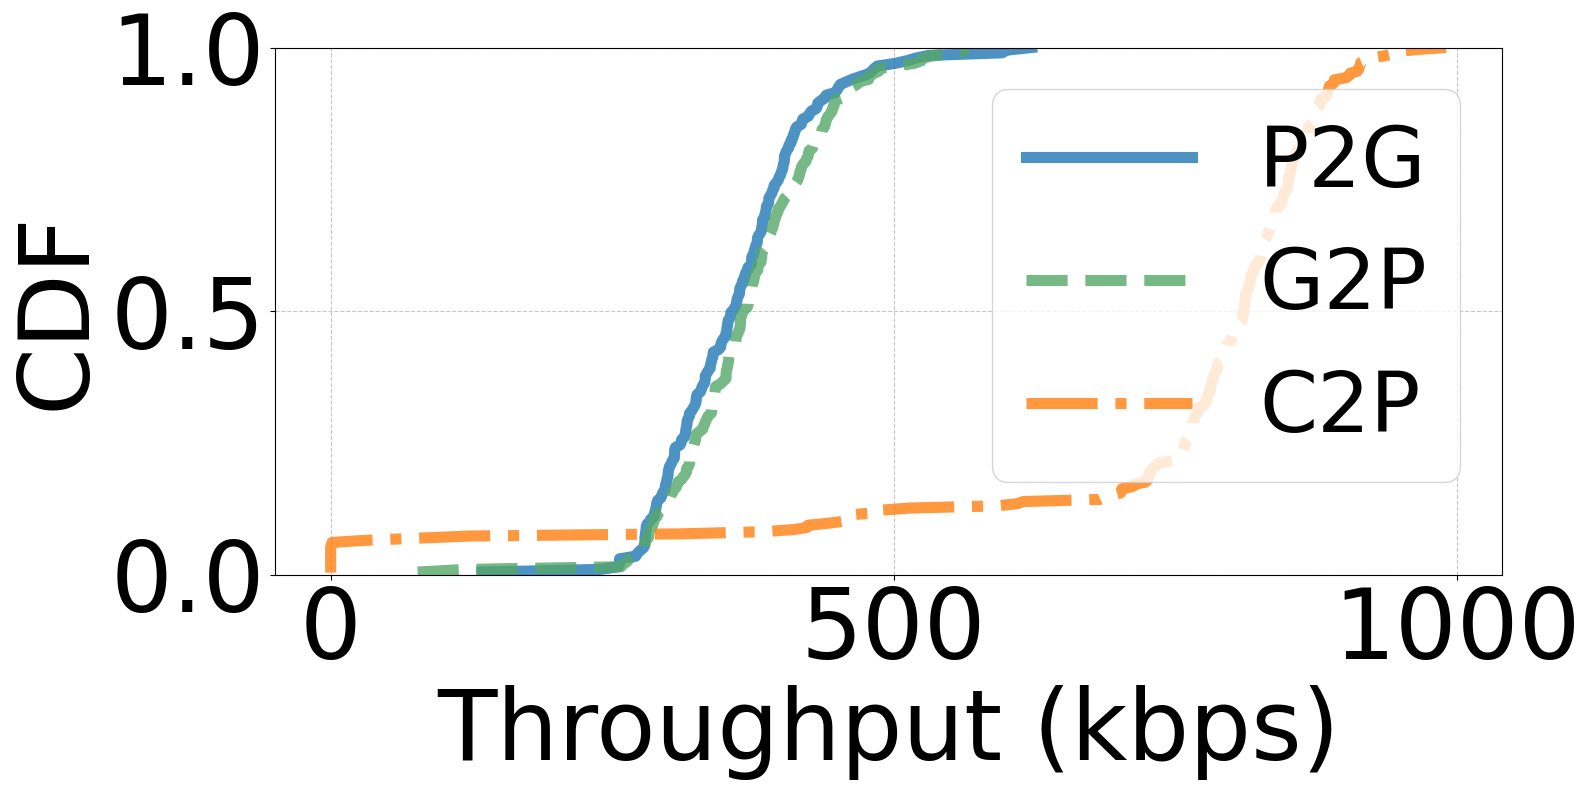

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
import re

# --- 1. Configuration: File Names ---
MESSENGER_LOG = 'RB_Display_G2P_test_Messenger_Cal.txt'
MESSENGER_S2P_CSV = 'NO_RB_Display_S2P_throughput_Messenger_Call_2.csv' 
MESSENGER_P2S_CSV = 'RB_Display_P2S_throughput_Messenger_Call_2.csv' 


WHATSAPP_LOG = 'RB_Display_G2P_test_Whatsapp_Call.txt'
WHATSAPP_S2P_CSV = 'RB_Display_S2P_test_Whatsapp_Call.csv' 
WHATSAPP_P2S_CSV = 'RB_Display_P2S_test_Whatsapp_Call.csv'

# --- 2. Helper Functions ---

def parse_log_file(filename):
    """
    Parses the text log file for G2P/P2G traffic.
    Filters specifically for L2CAP, RFCOMM, and Audio/Video protocols.
    """
    data = []
    TARGET_PROTOCOLS = ['L2CAP', 'RFCOMM', 'AVDTP', 'A2DP', 'SCO', 'ESCO']

    try:
        with open(filename, 'r') as f:
            print(f"Parsing {filename}...")
            for line in f:
                if not line.strip(): continue
                
                # --- PROTOCOL FILTER ---
                line_upper = line.upper()
                if not any(proto in line_upper for proto in TARGET_PROTOCOLS):
                    continue

                tokens = line.split()
                if len(tokens) < 6: continue
                
                # Parse Timestamp
                ts_str = ' '.join(tokens[0:3])
                try:
                    ts = datetime.datetime.strptime(ts_str, '%b %d %H:%M:%S.%f')
                    ts = ts.replace(year=2025)
                except ValueError: continue
                
                # Find Direction
                dir_idx = None
                direction = None
                for i in range(len(tokens) - 1, 2, -1):
                    if tokens[i] in ['SEND', 'RECV']:
                        dir_idx = i
                        direction = tokens[i]
                        break
                if not direction: continue
                
                # Find Handle
                handle_idx = None
                for i in range(3, dir_idx):
                    if tokens[i].startswith('0x'):
                        handle_idx = i
                        break
                if not handle_idx: continue
                
                # Extract Bytes
                full_desc = ' '.join(tokens[handle_idx + 1:dir_idx])
                bytes_ = None
                match = re.search(r'Length: 0x[0-9A-F]+ \((\d+)\)', full_desc, re.IGNORECASE)
                if match:
                    bytes_ = int(match.group(1))
                else:
                    match = re.search(r'(\d+) Bytes Of Data', full_desc, re.IGNORECASE)
                    if match:
                        bytes_ = int(match.group(1))
                
                if bytes_ is not None:
                    data.append({'timestamp': ts, 'direction': direction, 'bytes': bytes_})
                    
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
        return pd.DataFrame()
        
    return pd.DataFrame(data)

def calculate_throughput_timeseries(df, direction, window_seconds=1):
    """Calculates throughput in kbps using a time-based resampling window."""
    if df.empty: return []
    
    subset = df[df['direction'] == direction].copy()
    if subset.empty: return []
    
    subset = subset.set_index('timestamp')
    
    # Resample
    resampled = subset['bytes'].resample(f'{window_seconds}S').sum()
    
    # Convert to kbps
    throughput_kbps = (resampled * 8) / (window_seconds * 1000)
    
    return throughput_kbps[throughput_kbps > 0].values

def load_csv_s2p_data(filename):
    """Loads S2P throughput from CSV."""
    try:
        df = pd.read_csv(filename)
        if 'Filtered packets' in df.columns:
            return df['Filtered packets'].values * 0.001
        else:
            print(f"Warning: Column 'Filtered packets' not found in {filename}")
            return []
    except FileNotFoundError:
        print(f"Warning: S2P CSV file '{filename}' not found. Skipping.")
        return []

def plot_cdf(ax, data, label, color):
    if len(data) == 0:
        print(f"Skipping plot for {label} (No data)")
        return
    sorted_data = np.sort(data)
    yvals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, yvals, label=label, color=color, linewidth=3, alpha=0.8)

# --- 3. Process Data ---

# --- Messenger ---
df_mess = parse_log_file(MESSENGER_LOG)
mess_p2g = calculate_throughput_timeseries(df_mess, 'SEND')
mess_g2p = calculate_throughput_timeseries(df_mess, 'RECV')
mess_s2p = load_csv_s2p_data(MESSENGER_S2P_CSV)
mess_p2s = load_csv_s2p_data(MESSENGER_P2S_CSV)

# --- WhatsApp ---
df_wa = parse_log_file(WHATSAPP_LOG)
wa_p2g = calculate_throughput_timeseries(df_wa, 'SEND')
wa_g2p = calculate_throughput_timeseries(df_wa, 'RECV')
wa_s2p = load_csv_s2p_data(WHATSAPP_S2P_CSV)
was_p2s = load_csv_s2p_data(WHATSAPP_P2S_CSV)

# --- 4. Plotting (Separate Images) ---

# === PLOT 1: MESSENGER ===
plt.figure(figsize=(16, 8))
ax1 = plt.gca()

plot_cdf(ax1, mess_p2g, 'P2G', '#1f77b4')
plot_cdf(ax1, mess_g2p, 'G2P', '#55A868')
plot_cdf(ax1, mess_s2p, 'C2P', '#ff7f0e')
# plot_cdf(ax1, mess_p2s, 'P2S', '#8172B2')

# Set different linestyles for each curve
linestyles = ['-', '--', '-.', ':']
for idx, line in enumerate(ax1.get_lines()):
    line.set_linewidth(8)
    line.set_linestyle(linestyles[idx % len(linestyles)])

ax1.set_xlabel('Throughput (kbps)', fontsize=70)
ax1.set_ylabel('CDF', fontsize=70)
# ax1.set_title('Messenger Throughput CDF', fontsize=25)
ax1.grid(True, which='both', linestyle='--', alpha=0.7)
ax1.legend(fontsize=60, loc='upper right')
ax1.tick_params(axis='x', labelsize=70)
ax1.tick_params(axis='y', labelsize=70)
ax1.set_ylim(0, 1.0)
ax1.set_xlim(0, 2000) # As requested in your previous snippet

plt.tight_layout()
plt.savefig('../../Plots/Meta_Display_Messenger_Throughput_CDF.png', dpi=300)
plt.show() # This will open the first window

# === PLOT 2: WHATSAPP ===
plt.figure(figsize=(16, 8))
ax2 = plt.gca()

plot_cdf(ax2, wa_p2g, 'P2G', '#1f77b4')
plot_cdf(ax2, wa_g2p, 'G2P', '#55A868')
plot_cdf(ax2, wa_s2p, 'C2P', '#ff7f0e')
# plot_cdf(ax2, was_p2s, 'P2S', '#8172B2')

# Set different linestyles for each curve
linestyles = ['-', '--', '-.', ':']
for idx, line in enumerate(ax2.get_lines()):
    line.set_linewidth(8)
    line.set_linestyle(linestyles[idx % len(linestyles)])

ax2.tick_params(axis='x', labelsize=70)
ax2.tick_params(axis='y', labelsize=70)
ax2.set_xlabel('Throughput (kbps)', fontsize=70)
ax2.set_ylabel('CDF', fontsize=70)
# ax2.set_title('WhatsApp Throughput CDF', fontsize=25)
ax2.grid(True, which='both', linestyle='--', alpha=0.7)
ax2.legend(fontsize=60, loc='upper right')
ax2.set_ylim(0, 1.0)
# ax2.set_xlim(0, 2000) # Optional: Uncomment to match Messenger scale

plt.tight_layout()
plt.savefig('../../Plots/Meta_Display_WhatsApp_Throughput_CDF.png', dpi=300)
plt.show() # This will open the second window
